# Kernel Trick in SVM

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

findfont: Failed to find font weight normal, now using 700.


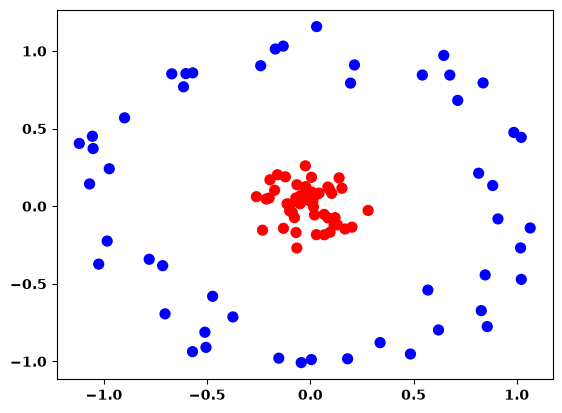

In [2]:
# Generating sample dataset
from sklearn.datasets._samples_generator import make_circles
X, y = make_circles(100, factor=0.1, noise=0.1)

plt.scatter(X[:, 0], X[:,1], c=y, s=50, cmap='bwr')

train with normal svm kernel - linear 

In [3]:
X_train , X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [4]:
classifier = SVC(kernel='linear')
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [5]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.4

In [6]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

C:\Users\praja\AppData\Local\Temp\ipykernel_28212\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
findfont: Failed to find font weight normal, now using 700.


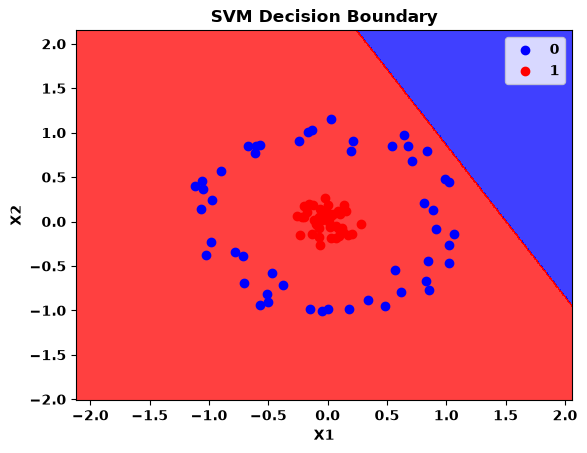

In [7]:
plot_decision_boundary(X, y, classifier)

In [8]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1)) # r = Radial Basis Function
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

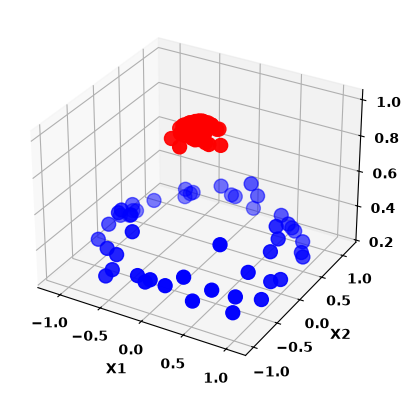

In [9]:
plot_3d_plot(X, y)

In [10]:
rbf_classifier = SVC(kernel='rbf')
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [11]:
accuracy_score(y_test, y_pred)

1.0

C:\Users\praja\AppData\Local\Temp\ipykernel_28212\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


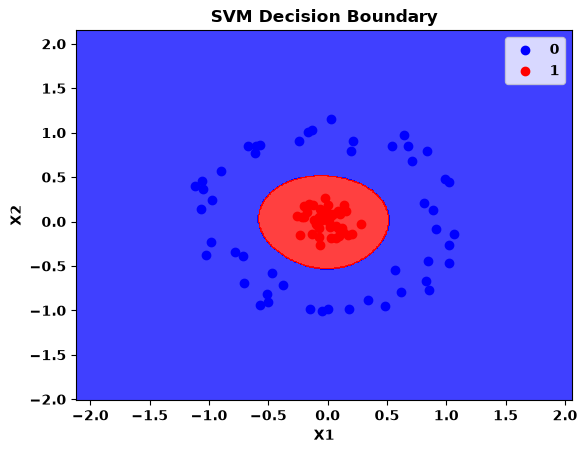

In [12]:
plot_decision_boundary(X, y, rbf_classifier)

In [19]:
# poly_classifier = SVC(kernel='poly', degree=2) --> it give accuracy score = 1.0
poly_classifier = SVC(kernel='poly')
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [20]:
accuracy_score(y_test, y_pred)

0.55

C:\Users\praja\AppData\Local\Temp\ipykernel_28212\3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


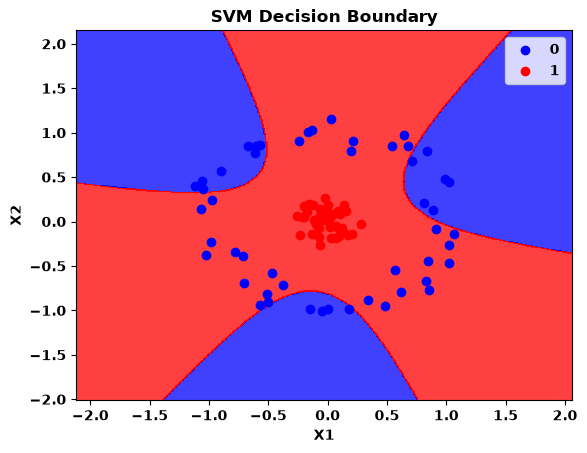

In [21]:
plot_decision_boundary(X, y, poly_classifier)

In [22]:
X

array([[ 1.80163432e-01, -9.83461197e-01],
       [-5.70156679e-01,  8.59500421e-01],
       [ 3.37608160e-01, -8.79101472e-01],
       [ 9.16818624e-02,  1.10907831e-01],
       [ 8.27628853e-01, -6.72831287e-01],
       [-4.92124352e-02,  6.63715700e-02],
       [ 8.14963439e-01,  2.12705702e-01],
       [ 6.46094462e-01,  9.71950945e-01],
       [ 1.30759570e-01, -1.20116306e-01],
       [-1.21289208e-01,  1.89525207e-01],
       [-1.00750663e-01, -2.96358461e-02],
       [-5.71406836e-01, -9.37122523e-01],
       [-5.06613966e-02,  1.54415024e-02],
       [ 4.42217694e-03, -9.88339791e-01],
       [-6.97791561e-02, -1.69566536e-01],
       [-2.29369998e-02,  1.26174546e-01],
       [-1.59854259e-01,  2.03032497e-01],
       [ 1.02139699e+00,  4.43726383e-01],
       [ 8.45027399e-02,  1.23841377e-01],
       [-7.04347396e-01, -6.93594627e-01],
       [-5.11235325e-01, -8.11970767e-01],
       [-4.44769184e-02, -1.00779214e+00],
       [-6.56950387e-02,  1.38440922e-01],
       [ 1.

In [24]:
np.exp(-(X**2)).sum(1)

array([1.34820978, 1.20018553, 1.35398594, 1.97940446, 1.14001324,
       1.99318557, 1.47046743, 1.04753291, 1.96872293, 1.95011426,
       1.98902275, 1.13697098, 1.9971983 , 1.37648861, 1.96679932,
       1.98368007, 1.93438622, 1.1735856 , 1.97766504, 1.22701703,
       1.28721752, 1.36019251, 1.97671007, 1.97227736, 1.3276019 ,
       1.96299719, 1.11977663, 1.99119312, 1.9239821 , 1.13436643,
       1.49583179, 1.95978963, 1.0279595 , 1.44076273, 1.15283521,
       1.99270721, 1.98995831, 1.99781443, 1.43284685, 1.9635676 ,
       1.96580874, 1.95089049, 1.21914049, 1.32998405, 1.1765917 ,
       1.92997793, 1.38407704, 1.20097817, 1.51277977, 1.30242668,
       1.14374742, 1.98257175, 1.96332469, 1.9804357 , 1.96210893,
       1.02841524, 1.92568591, 1.99071329, 1.95306176, 1.12333641,
       1.2978428 , 1.31047385, 1.98702654, 1.93379027, 1.95809422,
       1.22892346, 1.94227297, 1.21117823, 1.39210998, 1.28485258,
       1.43138381, 1.26091601, 1.99279293, 1.9928959 , 1.99977

In [25]:
X_new = np.exp(-(X**2))

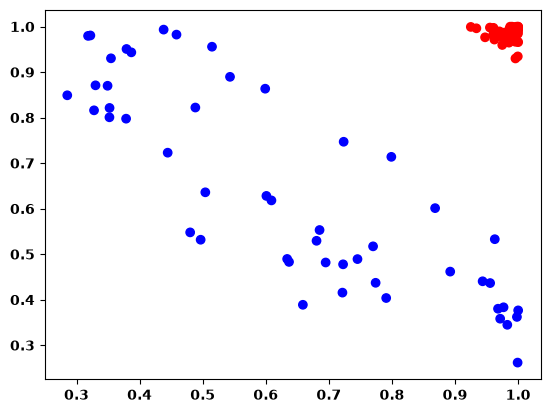

In [26]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, cmap='bwr')